<a href="https://colab.research.google.com/github/deepikaveerla27/AICTE_project/blob/master/Machine_Learning_Based_Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


First 5 Rows:
   Study_Hours  Attendance  Assignments  Previous_Marks  Sleep_Hours  \
0            2          75            6              60            6   
1            3          80            7              65            7   
2            5          90            8              80            7   
3            1          60            4              50            5   
4            6          95            9              88            8   

   Internet_Usage  Final_Score  
0               5           58  
1               4           66  
2               2           85  
3               6           48  
4               2           92  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     30 non-null     int64
 1   Attendance      30 non-null     int64
 2   Assignments     30 non-null     int64
 3   Previous_M

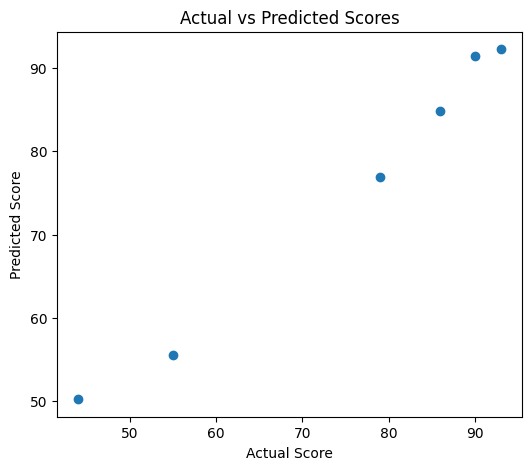

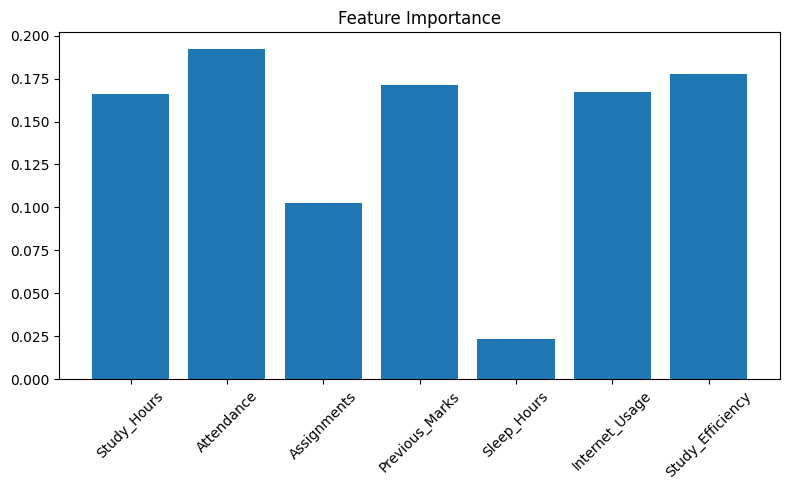


Predicted Final Score: 85.63


In [8]:
# ============================================
# Student Performance Prediction
# Machine Learning Project for Beginners
# ============================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# Step 2: Load Dataset
# ============================================

df = pd.read_csv("student_data.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ============================================
# Step 3: Check Missing Values
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# Step 4: Remove Duplicate Rows
# ============================================

df.drop_duplicates(inplace=True)

# ============================================
# Step 5: Feature Engineering
# ============================================

df["Study_Efficiency"] = df["Study_Hours"] * df["Attendance"]

print("\nDataset After Feature Engineering:")
print(df.head())

# ============================================
# Step 6: Define Features and Target
# ============================================

X = df.drop("Final_Score", axis=1)
y = df["Final_Score"]

# ============================================
# Step 7: Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Step 8: Feature Scaling
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# Step 9: Linear Regression
# ============================================

print("\n========== Linear Regression ==========")

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("R2  :", r2_score(y_test, lr_pred))

# ============================================
# Step 10: Decision Tree
# ============================================

print("\n========== Decision Tree ==========")

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("R2  :", r2_score(y_test, dt_pred))

# ============================================
# Step 11: Random Forest
# ============================================

print("\n========== Random Forest ==========")

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("R2  :", r2_score(y_test, rf_pred))

# ============================================
# Step 12: Hyperparameter Tuning
# ============================================

print("\nRunning GridSearchCV...")

parameters = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    parameters,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("\n========== Tuned Random Forest ==========")

print("MAE :", mean_absolute_error(y_test, best_pred))
print("MSE :", mean_squared_error(y_test, best_pred))
print("R2  :", r2_score(y_test, best_pred))

# ============================================
# Step 13: Actual vs Predicted
# ============================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_pred
})

print("\nPrediction Results:")
print(results)

# ============================================
# Step 14: Scatter Plot
# ============================================

plt.figure(figsize=(6,5))

plt.scatter(y_test, best_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.show()

# ============================================
# Step 15: Feature Importance
# ============================================

importance = best_model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,5))

plt.bar(feature_names, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

# ============================================
# Step 16: Predict New Student
# ============================================

new_student = pd.DataFrame({
    "Study_Hours":[5],
    "Attendance":[90],
    "Assignments":[8],
    "Previous_Marks":[80],
    "Sleep_Hours":[7],
    "Internet_Usage":[2],
    "Study_Efficiency":[5*90]
})

new_student_scaled = scaler.transform(new_student)

prediction = best_model.predict(new_student_scaled)

print("\nPredicted Final Score:", round(prediction[0],2))